In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score

import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [18]:
housing = pd.read_csv("Housing.csv")

In [4]:
housing.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
housing.shape

(545, 13)

In [6]:
housing.columns


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [9]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [19]:
#Step2: prepare data 
varlist = [ 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

In [20]:
housing[varlist] = housing[varlist].apply(lambda x: x.map({"yes":1, "no":0}))

In [21]:

housing[varlist].head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


In [55]:
name = ['Reetesh', 'Shruti', 'Kaustubh', 'Vikas', 'Mahima', 'Akshay']
response = ['No', 'Maybe', 'yes', 'Yes', 'maybe', 'Yes']

In [56]:
import pandas as pd 
df = pd.DataFrame({'Name': name,'Response': response})

In [57]:
df["Response"] = df["Response"].str.upper().map({"YES":1.0, "MAYBE":0.5,"NO":0.0})

In [58]:
df

,Name,Response
0,Reetesh,0.0
1,Shruti,0.5
2,Kaustubh,1.0
3,Vikas,1.0
4,Mahima,0.5
5,Akshay,1.0


In [60]:
x = ["A", "B", "AB", "O"]

In [61]:
df = pd.DataFrame({'Name': x})

In [62]:
status = pd.get_dummies(df)

In [66]:
status.drop(["Name_AB","Name_O"], axis=1)

,Name_A,Name_B
0,True,False
1,False,True
2,False,False
3,False,False


In [68]:
status_furniture = pd.get_dummies(housing["furnishingstatus"])

In [73]:
status_furniture = status_furniture.drop("furnished",axis=1)

In [74]:
status_furniture.head()

,semi-furnished,unfurnished
0,False,False
1,False,False
2,True,False
3,False,False
4,False,False


In [76]:
housing = pd.concat([housing,status_furniture], axis=1)

In [77]:
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,False,False


In [79]:
housing = housing.drop("furnishingstatus", axis=1)

In [80]:
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [81]:
housing["semi-furnished"] = housing["semi-furnished"].map({True:1, False:0})

In [82]:
housing["unfurnished"] = housing["unfurnished"].map({True:1, False:0})

In [83]:
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [91]:
df_train, df_test = train_test_split(housing)

df_train.shape,df_test.shape,

((408, 14), (137, 14))

In [88]:
df_train.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
426,3353000,2700,3,1,1,0,0,0,0,0,0,0,0,0
107,6125000,6420,3,1,3,1,0,1,0,0,0,1,0,1
364,3703000,3120,3,1,2,0,0,1,1,0,0,0,1,0
14,9240000,7800,3,2,2,1,0,0,0,0,0,1,1,0
277,4305000,10360,2,1,1,1,0,0,0,0,1,1,1,0


In [93]:
scaler = MinMaxScaler()

num_varlist = ["price","area","bedrooms","bathrooms","stories","mainroad"]

df_train[num_varlist] = scaler.fit_transform(df_train[num_varlist])



In [95]:
df_train.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
299,0.212121,0.367698,0.4,0.000000,0.0,1.0,0,0,0,0,3,0,0,0
368,0.166667,0.274227,0.2,0.000000,0.0,0.0,0,0,0,0,0,0,1,0
213,0.272121,0.229897,0.6,0.333333,0.0,1.0,0,1,0,0,0,0,1,0
87,0.409091,0.158763,0.4,0.000000,0.0,1.0,0,1,0,0,2,0,1,0
326,0.193939,0.168385,0.6,0.000000,0.0,0.0,0,1,0,0,0,0,0,1


In [97]:
df_train.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
count,408.000000,408.000000,408.000000,408.000000,408.000000,408.000000,408.000000,408.000000,408.000000,408.000000,408.000000,408.000000,408.000000,408.000000
mean,0.255319,0.238706,0.392647,0.086601,0.256536,0.843137,0.186275,0.350490,0.039216,0.308824,0.666667,0.227941,0.392157,0.343137
std,0.161557,0.152130,0.148522,0.162277,0.279592,0.364118,0.389806,0.477709,0.194346,0.462575,0.847987,0.420020,0.488831,0.475340
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142424,0.128522,0.200000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.222727,0.195876,0.400000,0.000000,0.333333,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.333333,0.323711,0.400000,0.000000,0.333333,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000


In [98]:
### Step 3 : training the model 

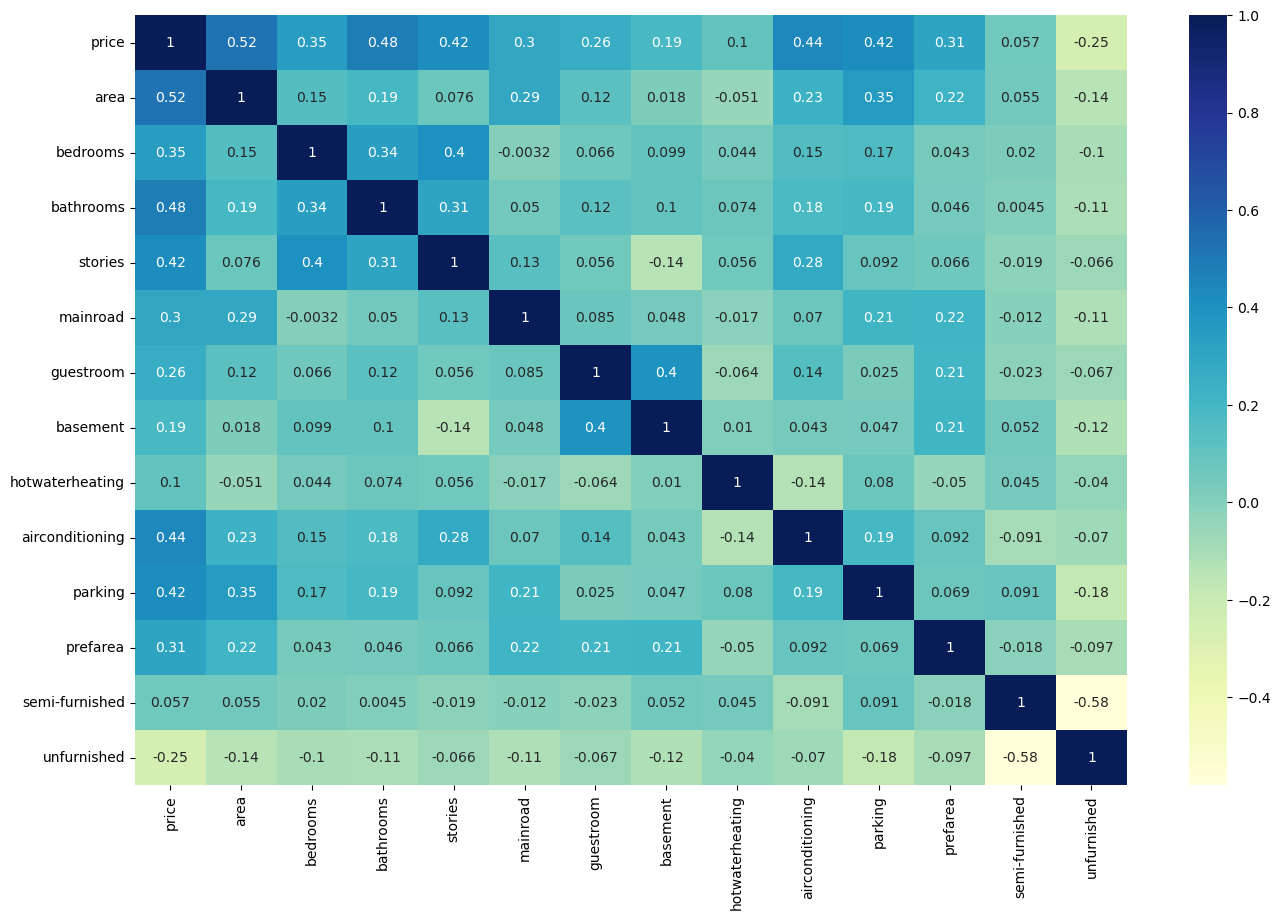

In [102]:
plt.figure(figsize=(16,10))

sns.heatmap(df_train.corr(), annot=True,cmap="YlGnBu")

plt.show()

In [103]:
y_train = df_train.pop("price")

X_train = df_train

In [104]:
X_train.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
299,0.367698,0.4,0.000000,0.0,1.0,0,0,0,0,3,0,0,0
368,0.274227,0.2,0.000000,0.0,0.0,0,0,0,0,0,0,1,0
213,0.229897,0.6,0.333333,0.0,1.0,0,1,0,0,0,0,1,0
87,0.158763,0.4,0.000000,0.0,1.0,0,1,0,0,2,0,1,0
326,0.168385,0.6,0.000000,0.0,0.0,0,1,0,0,0,0,0,1


In [106]:
X_train_sm = sm.add_constant(X_train['area'])

In [107]:
lr = sm.OLS(y_train, X_train_sm)

lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     151.4
Date:                Tue, 21 Jan 2025   Prob (F-statistic):           8.50e-30
Time:                        18:02:25   Log-Likelihood:                 229.99
No. Observations:                 408   AIC:                            -456.0
Df Residuals:                     406   BIC:                            -447.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1232      0.013      9.679      0.000       0.098       0.148
area           0.5535      0.045     12.306      0.000       0.465       0.642
==============================================================================
Omnibus:                       79.707   Durbin-Watson:                   1.993
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              159.907
Skew:                           1.050   Prob(JB):                     1.89e-35
Kurtosis:                       5.235   Cond. No.                         6.96
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [110]:
X_train.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
299,0.367698,0.4,0.000000,0.0,1.0,0,0,0,0,3,0,0,0
368,0.274227,0.2,0.000000,0.0,0.0,0,0,0,0,0,0,1,0
213,0.229897,0.6,0.333333,0.0,1.0,0,1,0,0,0,0,1,0
87,0.158763,0.4,0.000000,0.0,1.0,0,1,0,0,2,0,1,0
326,0.168385,0.6,0.000000,0.0,0.0,0,1,0,0,0,0,0,1


In [112]:
# ading another variable bathrooms

X_train_sm = X_train[['area', 'bathrooms']]

X_train_sm = sm.add_constant(X_train_sm)

lr = sm.OLS(y_train, X_train_sm)

lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.423
Model:                            OLS   Adj. R-squared:                  0.420
Method:                 Least Squares   F-statistic:                     148.7
Date:                Tue, 21 Jan 2025   Prob (F-statistic):           3.88e-49
Time:                        18:07:09   Log-Likelihood:                 277.61
No. Observations:                 408   AIC:                            -549.2
Df Residuals:                     405   BIC:                            -537.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1082      0.011      9.469      0.000       0.086       0.131
area           0.4728      0.041     11.581      0.000       0.393       0.553
bathrooms      0.3950      0.038     10.320      0.000       0.320       0.470
==============================================================================
Omnibus:                       73.802   Durbin-Watson:                   2.082
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              153.867
Skew:                           0.961   Prob(JB):                     3.87e-34
Kurtosis:                       5.315   Cond. No.                         7.44
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [113]:
# ading another variable bedrooms

X_train_sm = X_train[['area', 'bathrooms','bedrooms']]

X_train_sm = sm.add_constant(X_train_sm)

lr = sm.OLS(y_train, X_train_sm)

lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.447
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     108.7
Date:                Tue, 21 Jan 2025   Prob (F-statistic):           1.29e-51
Time:                        18:08:12   Log-Likelihood:                 286.06
No. Observations:                 408   AIC:                            -564.1
Df Residuals:                     404   BIC:                            -548.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0468      0.019      2.510      0.012       0.010       0.083
area           0.4573      0.040     11.370      0.000       0.378       0.536
bathrooms      0.3427      0.040      8.650      0.000       0.265       0.421
bedrooms       0.1776      0.043      4.132      0.000       0.093       0.262
==============================================================================
Omnibus:                       62.800   Durbin-Watson:                   2.102
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              122.060
Skew:                           0.855   Prob(JB):                     3.13e-27
Kurtosis:                       5.064   Cond. No.                         9.17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [114]:


# ading another variable airconditioning

X_train_sm = X_train[['area', 'bathrooms','bedrooms', 'airconditioning']]

X_train_sm = sm.add_constant(X_train_sm)

lr = sm.OLS(y_train, X_train_sm)

lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                     108.1
Date:                Tue, 21 Jan 2025   Prob (F-statistic):           1.69e-62
Time:                        18:10:19   Log-Likelihood:                 314.03
No. Observations:                 408   AIC:                            -618.1
Df Residuals:                     403   BIC:                            -598.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0438      0.017      2.511      0.012       0.010       0.078
area                0.3990      0.038     10.402      0.000       0.324       0.474
bathrooms           0.3123      0.037      8.386      0.000       0.239       0.386
bedrooms            0.1512      0.040      3.749      0.000       0.072       0.230
airconditioning     0.0969      0.013      7.696      0.000       0.072       0.122
==============================================================================
Omnibus:                       74.964   Durbin-Watson:                   2.083
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              162.168
Skew:                           0.960   Prob(JB):                     6.11e-36
Kurtosis:                       5.419   Cond. No.                         9.61
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Building model with all variables 

In [115]:
X_train_sm = X_train

X_train_sm = sm.add_constant(X_train_sm)

lr = sm.OLS(y_train, X_train_sm)

lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     58.86
Date:                Tue, 21 Jan 2025   Prob (F-statistic):           7.78e-84
Time:                        20:22:50   Log-Likelihood:                 385.45
No. Observations:                 408   AIC:                            -742.9
Df Residuals:                     394   BIC:                            -686.7
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0200      0.021      0.947      0.344      -0.022       0.062
area                0.2962      0.036      8.216      0.000       0.225       0.367
bedrooms            0.0477      0.037      1.287      0.199      -0.025       0.120
bathrooms           0.2313      0.033      7.076      0.000       0.167       0.296
stories             0.1244      0.020      6.083      0.000       0.084       0.165
mainroad            0.0364      0.014      2.565      0.011       0.009       0.064
guestroom           0.0321      0.014      2.345      0.020       0.005       0.059
basement            0.0310      0.011      2.692      0.007       0.008       0.054
hotwaterheating     0.0911      0.025      3.631      0.000       0.042       0.140
airconditioning     0.0747      0.011      6.562      0.000       0.052       0.097
parking             0.0294      0.006      4.715      0.000       0.017       0.042
prefarea            0.0515      0.012      4.232      0.000       0.028       0.075
semi-furnished     -0.0026      0.012     -0.210      0.834      -0.027       0.021
unfurnished        -0.0308      0.013     -2.414      0.016      -0.056      -0.006
==============================================================================
Omnibus:                       72.045   Durbin-Watson:                   2.050
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              182.855
Skew:                           0.866   Prob(JB):                     1.97e-40
Kurtosis:                       5.785   Cond. No.                         15.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [120]:
vif = pd.DataFrame()
vif['Features'] = X_train.columns
vif['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif['VIF'] = round(vif['VIF'],2)

vif = vif.sort_values(by="VIF", ascending= False)
vif

,Features,VIF
1,bedrooms,7.13
4,mainroad,5.49
0,area,4.54
3,stories,2.66
11,semi-furnished,2.13
6,basement,2.04
9,parking,2.01
12,unfurnished,1.89
8,airconditioning,1.76
2,bathrooms,1.59


In [121]:
X = X_train.drop("semi-furnished", axis=1)

In [122]:
# X_train_sm = X_train

X_train_sm = sm.add_constant(X)

lr = sm.OLS(y_train, X_train_sm)

lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     63.91
Date:                Tue, 21 Jan 2025   Prob (F-statistic):           9.72e-85
Time:                        20:35:40   Log-Likelihood:                 385.43
No. Observations:                 408   AIC:                            -744.9
Df Residuals:                     395   BIC:                            -692.7
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0181      0.019      0.949      0.343      -0.019       0.056
area                0.2959      0.036      8.224      0.000       0.225       0.367
bedrooms            0.0478      0.037      1.294      0.196      -0.025       0.121
bathrooms           0.2316      0.033      7.100      0.000       0.167       0.296
stories             0.1244      0.020      6.088      0.000       0.084       0.165
mainroad            0.0367      0.014      2.596      0.010       0.009       0.064
guestroom           0.0322      0.014      2.358      0.019       0.005       0.059
basement            0.0309      0.011      2.691      0.007       0.008       0.053
hotwaterheating     0.0911      0.025      3.636      0.000       0.042       0.140
airconditioning     0.0750      0.011      6.667      0.000       0.053       0.097
parking             0.0294      0.006      4.716      0.000       0.017       0.042
prefarea            0.0516      0.012      4.258      0.000       0.028       0.075
unfurnished        -0.0292      0.010     -2.837      0.005      -0.049      -0.009
==============================================================================
Omnibus:                       72.368   Durbin-Watson:                   2.049
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              184.239
Skew:                           0.869   Prob(JB):                     9.84e-41
Kurtosis:                       5.796   Cond. No.                         15.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [123]:
vif = pd.DataFrame()
vif['Features'] = X_train.columns
vif['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif['VIF'] = round(vif['VIF'],2)

vif = vif.sort_values(by="VIF", ascending= False)
vif

,Features,VIF
1,bedrooms,7.13
4,mainroad,5.49
0,area,4.54
3,stories,2.66
11,semi-furnished,2.13
6,basement,2.04
9,parking,2.01
12,unfurnished,1.89
8,airconditioning,1.76
2,bathrooms,1.59


In [124]:
X = X.drop("bedrooms", axis=1)


In [125]:
X_train_sm = sm.add_constant(X)

lr = sm.OLS(y_train, X_train_sm)

lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.659
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     69.45
Date:                Tue, 21 Jan 2025   Prob (F-statistic):           2.60e-85
Time:                        20:37:42   Log-Likelihood:                 384.56
No. Observations:                 408   AIC:                            -745.1
Df Residuals:                     396   BIC:                            -697.0
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0337      0.015      2.269      0.024       0.005       0.063
area                0.3003      0.036      8.377      0.000       0.230       0.371
bathrooms           0.2397      0.032      7.479      0.000       0.177       0.303
stories             0.1338      0.019      7.013      0.000       0.096       0.171
mainroad            0.0345      0.014      2.460      0.014       0.007       0.062
guestroom           0.0315      0.014      2.309      0.021       0.005       0.058
basement            0.0331      0.011      2.912      0.004       0.011       0.055
hotwaterheating     0.0910      0.025      3.630      0.000       0.042       0.140
airconditioning     0.0748      0.011      6.643      0.000       0.053       0.097
parking             0.0301      0.006      4.845      0.000       0.018       0.042
prefarea            0.0513      0.012      4.229      0.000       0.027       0.075
unfurnished        -0.0297      0.010     -2.880      0.004      -0.050      -0.009
==============================================================================
Omnibus:                       75.069   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              195.750
Skew:                           0.891   Prob(JB):                     3.12e-43
Kurtosis:                       5.887   Cond. No.                         13.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [127]:
vif = pd.DataFrame()
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'],2)

vif = vif.sort_values(by="VIF", ascending= False)
vif

,Features,VIF
3,mainroad,4.68
0,area,4.14
2,stories,2.23
8,parking,2.00
5,basement,1.87
7,airconditioning,1.74
1,bathrooms,1.55
4,guestroom,1.54
9,prefarea,1.48
10,unfurnished,1.37


In [128]:
y_train_pred = lr_model.predict(X_train_sm)

In [130]:
res = y_train - y_train_pred

<Axes: ylabel='Density'>

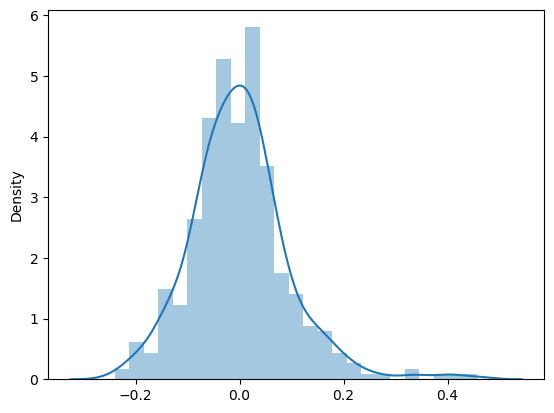

In [133]:
sns.distplot(res)

### Step 4 prediction

In [137]:
num_varlist = ["price","area","bedrooms","bathrooms","stories","mainroad"]

df_test[num_varlist] = scaler.transform(df_test[num_varlist])



In [135]:
df_test.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
359,0.169697,0.134021,0.4,0.000000,0.000000,1.0,0,0,0,0,1,0,0,1
134,0.350909,0.367698,0.4,0.000000,0.000000,1.0,0,1,0,0,2,1,1,0
3,0.906061,0.402062,0.6,0.333333,0.333333,1.0,0,1,0,1,3,1,0,0
465,0.112121,0.147766,0.2,0.000000,0.000000,1.0,0,0,0,0,0,0,0,1
163,0.318182,0.355670,0.4,0.000000,0.000000,1.0,1,1,0,1,0,1,1,0


In [139]:
df_test.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
count,1.370000e+02,137.000000,1.370000e+02,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,-1.515151e-01,-0.113385,-1.211679e-01,-0.292782,-0.231955,0.905109,0.153285,0.350365,0.065693,0.335766,0.773723,0.255474,0.489051,0.277372
std,1.406242e-08,0.000010,2.908066e-02,0.060071,0.104783,0.294139,0.361584,0.478835,0.248655,0.473991,0.899286,0.437728,0.501715,0.449345
min,-1.515151e-01,-0.113400,-1.600000e-01,-0.333333,-0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-1.515151e-01,-0.113393,-1.600000e-01,-0.333333,-0.333333,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-1.515151e-01,-0.113386,-1.200000e-01,-0.333333,-0.222222,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,-1.515151e-01,-0.113380,-1.200000e-01,-0.222222,-0.222222,1.000000,0.000000,1.000000,0.000000,1.000000,2.000000,1.000000,1.000000,1.000000
max,-1.515151e-01,-0.113348,5.551115e-17,-0.111111,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000


In [140]:
y_test = df_test.pop("price")
X_test = df_test

In [146]:
X_test_sm = sm.add_constant(X_test)

In [142]:
X_test_sm.head()

,const,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
359,1.0,-0.113393,-0.12,-0.333333,-0.333333,1.0,0,0,0,0,1,0,0,1
134,1.0,-0.113377,-0.12,-0.333333,-0.333333,1.0,0,1,0,0,2,1,1,0
3,1.0,-0.113374,-0.08,-0.222222,-0.222222,1.0,0,1,0,1,3,1,0,0
465,1.0,-0.113392,-0.16,-0.333333,-0.333333,1.0,0,0,0,0,0,0,0,1
163,1.0,-0.113378,-0.12,-0.333333,-0.333333,1.0,1,1,0,1,0,1,1,0


In [147]:
X_test_sm = X_test_sm.drop(["bedrooms","semi-furnished"], axis=1)

In [148]:
# predict

y_test_pred = lr_model.predict(X_test_sm)

In [150]:
#evaluate

r2_score(y_true= y_test, y_pred=y_test_pred)

-159598568143940.12